# Loading gravitatational-wave data from SFDBs and running the Hough transform

Need to do injection part, first sinusoid, then sinusoid plus fdot, then doppler shift, then add antenna patterns


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/andrew-l-miller/gwosc/blob/main/create_sfdbs/searching_and_injecting_with_SFDBs_and_FH.ipynb)


In [1]:
from pathlib import Path
import os
import requests
import argparse
import matplotlib.pyplot as plt
import numpy as np
import scipy
import glob


In [28]:
import pyhough
import pyfstat
from read_sfdb import *
from pyhough import pm
from pyhough import hm

26-01-29 15:12:09.557 pyfstat INFO    : Running PyFstat version 2.0.2


### what the SDFB header contains

`SFDBheader:
  eof             = 0
  endian          = 1.0
  detector        = 2
  gps_sec         = 1369185280
  gps_nsec        = 0
  tbase           = 1024.0
  firstfrind      = 0
  nsamples        = 2097152
  red             = 128
  typ             = 2
  n_flag          = -1.0
  einstein        = 1.0
  mjdtime         = 60091.05164351852
  nfft            = 7
  wink            = 5
  normd           = 7.62939453125e-06
  normw           = 1.2066189050674438
  frinit          = 0.0
  tsamplu         = 0.000244140625
  deltanu         = 0.0009765625
  vx_eq           = 1.22345e-319
  vy_eq           = 4.015697475586e-312
  vz_eq           = 0.0
  px_eq           = 1.034068651e-314
  py_eq           = 2.068136562e-314
  pz_eq           = 3.1022049663e-314
  n_zeroes        = 0
  sat_howmany     = 0.0
  spare1          = 0.0
  spare2          = 0.0
  spare3          = 0.0
  spare4          = 0.0
  spare5          = 0.0
  spare6          = 0.0
  lavesp          = 16384
  spare8          = 1
  spare9          = 0`

In [83]:
sfdb_files = glob.glob("/Users/andrewmiller/Downloads/*.SFDB09")

if not sfdb_files:
    raise FileNotFoundError("No .SFDB09 files found in the current directory.")
else:
    sfdb_file = sfdb_files[0]
    print(f"Using SFDB file: {sfdb_file}")
minf = 1205
maxf = minf + 1

allt0s = []
spec_rows = []   # list of 1D arrays (each is eq_power or band-cut)
all_vsss = []   # will become (3, N)
all_psss = []

with open(sfdb_file, "rb") as f:
    while True:
        sfdb_head, _, sps, sft = sfdb_read_an_FFT(f, det=0, want_sft=True, endian="<")
        if sfdb_head == 0:
            break
        tfft = sfdb_head.tbase
        freqs = np.arange(sfdb_head.nsamples) * sfdb_head.deltanu
        norm_factor = sfdb_head.normd*sfdb_head.normw*np.sqrt(2)
        sps_full = np.repeat(sps, sfdb_head.red) / norm_factor
        eq_power = np.abs(sft)**2 / sps_full ** 2

        in_band = (freqs >= minf) & (freqs <= maxf)
        spec_rows.append(eq_power[in_band])
        allt0s.append(sfdb_head.gps_sec)
        

spec = np.vstack(spec_rows).T  # shape: (nfreq_in_band, ntime)
allt0s = np.array(allt0s)
band_freqs = freqs[in_band]
t_rel = allt0s - allt0s[0]


Using SFDB file: /Users/andrewmiller/Downloads/H1_GWOSC-4KHZ_R1_STRAIN_20230527_002310.SFDB09


/var/folders/6s/_5vmyy4j3_n0rj1ml0227bq80000gn/T/ipykernel_5971/1416828732.py:25: RuntimeWarning: invalid value encountered in divide
  eq_power = np.abs(sft)**2 / sps_full ** 2


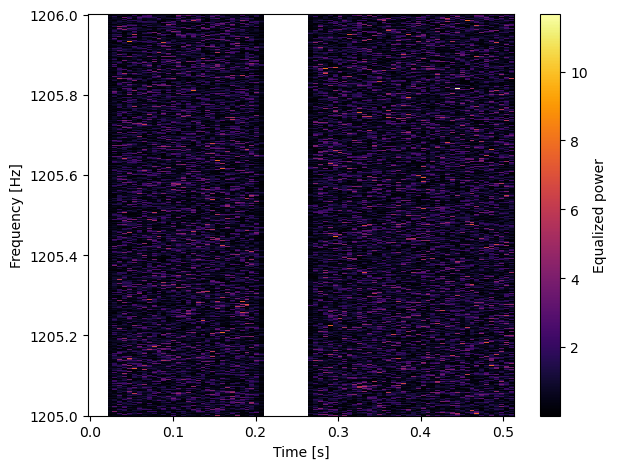

In [127]:
plt.figure()

im = plt.pcolormesh(
    t_rel / 86400,
    band_freqs,
    spec,
    shading="auto",
    cmap="inferno"
)

plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")
plt.colorbar(im, label="Equalized power")

plt.tight_layout()
plt.show()

In [91]:
threshold = 2.5
ifo = 'H1'
pm_times,pm_freqs,pm_pows,index = pyhough.pm.make_peakmap_from_spectrogram(allt0s,band_freqs,spec,threshold)

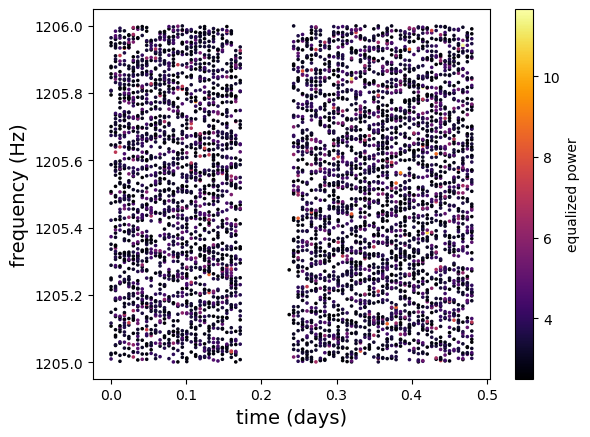

In [92]:
pyhough.pm.python_plot_triplets((pm_times-pm_times[0])/86400,pm_freqs,pm_pows,'.',label='equalized power')

plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);

In [101]:
def get_detector_velocities(gps_time_arr,tfft,ifo):



    mds = pyfstat.DetectorStates().get_multi_detector_states(
        timestamps=gps_time_arr,
        Tsft=tfft,
        detectors=ifo,
    )

    det_series = mds.data[0]
    states = det_series.data

    N = len(states)
    vs = np.empty((N, 3))

    for i, state in enumerate(states):
        vs[i, :] = state.vDetector.data
    return vs



Nts = len(allt0s)
position = [50., -20.]
vec_n = pyhough.pm.astro2rect(position,1)
vs = get_detector_velocities(allt0s,tfft,ifo)
freqs_new=pyhough.pm.remove_doppler_from_peakmap(pm_times,pm_freqs,index,vec_n,vs.T,Nts)

26-01-29 18:19:44.942 pyfstat.utils.ephemeris INFO    : No /Users/andrewmiller/.pyfstat.conf file found. Will fall back to lal's automatic path resolution for files [earth00-40-DE405.dat.gz,sun00-40-DE405.dat.gz]. Alternatively, set 'earth_ephem' and 'sun_ephem' class options.


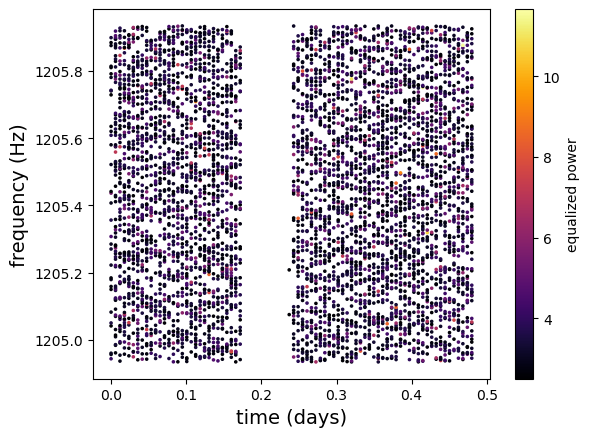

In [102]:
pyhough.pm.python_plot_triplets((pm_times-pm_times[0])/86400,freqs_new,pm_pows,'.',label='equalized power')

plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);

In [123]:
df = 1/tfft # the frequency bin size
Tobs = np.max(allt0s-allt0s[0]) # the duration of the peakmap in seconds
ref_perc_time = 0.5 * 100 # reference time for the Hough at which f0 is determined, set any number between 0 (beginning), 100 (end)
dsd = 1/(tfft*Tobs) # step in spin-down: dsd = df / Tobs
# sdgrid = pyhough.hm.make_sd_grid(sig_fdot,dsd) ## grid of spin-downs to search over
min_fdot_search = -10 * dsd
max_fdot_search = 10 * dsd 
sdgrid = np.arange(min_fdot_search,max_fdot_search,dsd)

In [124]:
hmap_from_pm = pyhough.hm.hfdf_hough(pm_times,freqs_new,tfft,sdgrid,ref_perc_time)
fs_for_hmap_from_pm = np.arange(np.min(freqs_new),np.max(freqs_new),df)

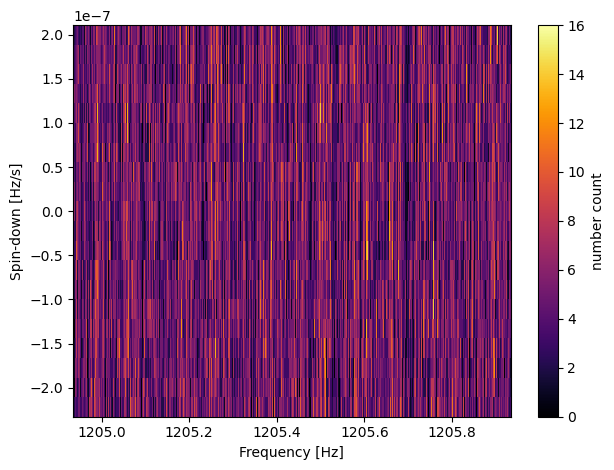

In [125]:
fig, ax = plt.subplots()#figsize=(0.8 * 16, 0.8 * 9))
ax.set(ylabel="Spin-down [Hz/s]", xlabel=r"Frequency [Hz]")#, ylim=(99.98, 100.02))
c = ax.pcolormesh(
    fs_for_hmap_from_pm,
    sdgrid,
    hmap_from_pm,
    cmap="inferno",
    shading="nearest",
)
fig.colorbar(c, label="number count")
plt.tight_layout()
# ax.set(ylim=(sig_fdot*1.3,-0.7e-9));
# ax.set(xlim=(99.975,100.025));
# plt.savefig('hm_map.jpg',format='png',dpi=400)

### Do an injection

In [ ]:

def phase_from_frequency(inject_fs, tt):
    """
    inject_fs : array of instantaneous frequencies [Hz]
    tt        : array of times [s], same length

    returns
    -------
    phase : array of phase [rad]
    """
    inject_fs = np.asarray(inject_fs, dtype=float)
    tt = np.asarray(tt, dtype=float)

    dt = np.zeros_like(tt)
    dt[1:] = np.diff(tt)

    phase_cycles = np.cumsum(inject_fs * dt)
    phase = np.mod(phase_cycles, 1.0) * 2.0 * np.pi
    return phase


def inject_into_sft(
    sft: np.ndarray,
    freqs: np.ndarray,
    sps_full: np.ndarray,
    t0_gps: float,
    tbase: float,
    waveform_fn,
):
    """
    Modify SFT in-place by adding a complex signal into one frequency bin.

    Parameters
    ----------
    sft : complex ndarray, shape (nsamples,)
        Complex SFT bins (as returned by sfdb_read_an_FFT with want_sft=True).
    freqs : float ndarray, shape (nsamples,)
        Frequency of each bin (Hz).
    sps_full : float ndarray, shape (nsamples,)
        Noise ASD-like array used in your eq_power normalization (same length as sft).
        (You already compute this as np.repeat(sps, red)/norm_factor.)
    t0_gps : float
        SFT start time (from sfdb_head.gps_sec).
    tbase : float
        SFT duration (from sfdb_head.tbase).
    waveform_fn : callable
        Called as waveform_fn(t_mid) and must return (f_hz, dp, phase)
        where:
          - f_hz: injected frequency in Hz
          - dp: desired *added* eq_power in that bin (dimensionless)
          - phase: phase in radians (can be 0.0 or random)
    """

    amps, fs = waveform_fn(t_mid)

    # nearest bin
    phase = phase_from_frequency(inject_fs, tt);
    sig = (amp * np.exp(1j * phase) ## need to include antenna pattern 
    sft = sft +  np.fft.fft(sig)

    return sft
